In [1]:
%run shared_imports.py

In [2]:
engine = make_engine("settings.toml")
session = Session(engine)

import seaborn as sns
sns.set_theme()

In [3]:
query = session.query(Feedback.json).join(Round).filter(
        Feedback.key_name == "ghost_spawns",
        Round.start_datetime >= datetime(2024, 10, 1),
        Round.start_datetime < datetime(2024, 10, 28))

prod_ghost_spawns = pd.read_sql_query(query.statement, session.connection())

In [4]:
prod_ghost_spawns

,json
0,"{'data': {'Syndicate Researcher': 2, 'Hermit':..."
1,"{'data': {'Ghost Bar Occupant': 2, 'Syndicate ..."
2,"{'data': {'Free Golem': 1, 'Syndicate Research..."
3,"{'data': {'Ghost Bar Occupant': 3, 'Ash Walker..."
4,"{'data': {'Ghost Bar Occupant': 3, 'Syndicate ..."
...,...
266,"{'data': {'Ghost Bar Occupant': 2, 'Hermit': 1..."
267,{'data': {'Ghost Bar Occupant': 5}}
268,"{'data': {'Hermit': 1, 'Seed Vault Diona': 1, ..."
269,"{'data': {'Ancient Crew': 2, 'Ghost Bar Occupa..."


In [5]:
pd.json_normalize(prod_ghost_spawns.json)

,data.Syndicate Researcher,data.Hermit,data.Ancient Crew,data.Ghost Bar Occupant,data.Free Golem,data.Ash Walker,data.Seed Vault Diona,data.Ghost Role
0,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN
1,1.0,NaN,NaN,2.0,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN
3,3.0,NaN,1.0,3.0,NaN,1.0,NaN,NaN
4,3.0,NaN,NaN,3.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
266,NaN,1.0,NaN,2.0,1.0,NaN,NaN,NaN
267,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN
268,2.0,1.0,1.0,NaN,NaN,NaN,1.0,NaN
269,NaN,NaN,2.0,1.0,NaN,NaN,NaN,NaN


In [17]:
normalized = pd.json_normalize(prod_ghost_spawns.json)
normalized.columns = normalized.columns.str.replace("data.", "")

In [18]:
normalized.fillna(0).astype(int)

,Syndicate Researcher,Hermit,Ancient Crew,Ghost Bar Occupant,Free Golem,Ash Walker,Seed Vault Diona,Ghost Role
0,2,1,1,0,0,0,0,0
1,1,0,0,2,0,0,0,0
2,4,0,0,0,1,0,0,0
3,3,0,1,3,0,1,0,0
4,3,0,0,3,0,0,0,0
...,...,...,...,...,...,...,...,...
266,0,1,0,2,1,0,0,0
267,0,0,0,5,0,0,0,0
268,2,1,1,0,0,0,1,0
269,0,0,2,1,0,0,0,0


In [8]:
normalized = pd.json_normalize(prod_ghost_spawns.json)
normalized.columns = normalized.columns.str.replace("data.", "")

In [9]:
normalized = normalized.drop('Ghost Role', axis=1)

In [10]:
normalized.fillna(0).astype(int)

,Syndicate Researcher,Hermit,Ancient Crew,Ghost Bar Occupant,Free Golem,Ash Walker,Seed Vault Diona
0,2,1,1,0,0,0,0
1,1,0,0,2,0,0,0
2,4,0,0,0,1,0,0
3,3,0,1,3,0,1,0
4,3,0,0,3,0,0,0
...,...,...,...,...,...,...,...
266,0,1,0,2,1,0,0
267,0,0,0,5,0,0,0
268,2,1,1,0,0,0,1
269,0,0,2,1,0,0,0


In [11]:
normalized = pd.json_normalize(prod_ghost_spawns.json)
normalized.columns = normalized.columns.str.replace("data.", "")
# normalized.drop('Ghost Role', axis=1)
normalized = normalized.fillna(0).astype(int)

In [12]:
normalized

,Syndicate Researcher,Hermit,Ancient Crew,Ghost Bar Occupant,Free Golem,Ash Walker,Seed Vault Diona,Ghost Role
0,2,1,1,0,0,0,0,0
1,1,0,0,2,0,0,0,0
2,4,0,0,0,1,0,0,0
3,3,0,1,3,0,1,0,0
4,3,0,0,3,0,0,0,0
...,...,...,...,...,...,...,...,...
266,0,1,0,2,1,0,0,0
267,0,0,0,5,0,0,0,0
268,2,1,1,0,0,0,1,0
269,0,0,2,1,0,0,0,0


In [20]:
normalized.drop('Ghost Role', inplace=True, axis=1)

In [21]:
counts = normalized.sum().sort_values(ascending=[False])

In [15]:
counts = normalized.count()

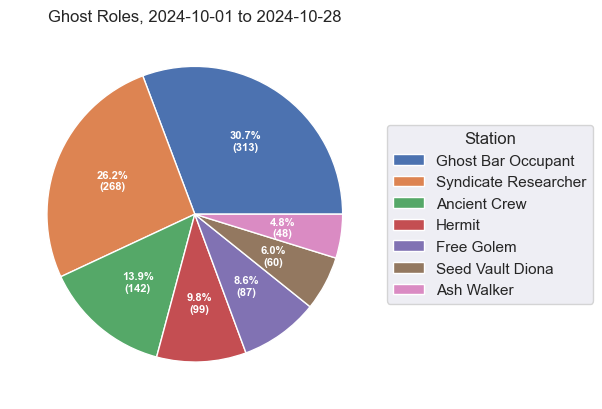

In [23]:
fig, ax = plt.subplots()
# fig.set_size_inches(7, 6)

def func(pct, allvals):
    absolute = int(pct/100.*np.sum(allvals))
    return "{:.1f}%\n({:d})".format(pct, absolute)

wedges, texts, autotexts = ax.pie(counts, autopct=lambda pct: func(pct, counts), textprops=dict(color="w"))
ax.legend(wedges, counts.index, title="Station", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.setp(autotexts, size=8, weight="bold")
ax.set_title("Ghost Roles, 2024-10-01 to 2024-10-28")
# plt.show()
plt.savefig('ghost_roles_pie_2024-10-01_2024-10-28.png')